# 🤖 Day 1 — The Robotics Stack & Your First ROS 2 Graph

### *Robotics From Scratch* · Phase A: Foundations · Notebook 1 of 45

**Time:** ~2–3 hrs &nbsp;•&nbsp; **Mode:** Ubuntu 24.04 + ROS 2 Jazzy (terminal) + this notebook as your lesson &nbsp;•&nbsp; **Phase goal:** *think in frames and nodes.*

---

> **How to use this notebook.** It's a **lesson**, not a program. Markdown cells are the teaching. Bash blocks (```` ```bash ````) are commands you copy into a **real terminal** — ROS 2 nodes are long-running and need several terminals, so we don't run them inside Jupyter. A few **code cells are meant to run here** (they're labeled ▶️ RUN ME) — those draw diagrams or write files for you. Work top to bottom. Don't skip the **🏋️ Stretch** or the **📓 Log** — that's where the learning sticks.

**Today in one sentence:** you'll install the mental model of *what a robot even is as a system*, then make three ROS 2 programs talk to each other and *see* the conversation graph — and write your very first node.

## 🎯 What you'll be able to do by the end

1. Explain a robot as a **Sense → Estimate → Plan → Act** loop glued by **transforms** — and place any topic you meet into one of those boxes.
2. Describe what a **node**, a **topic**, and a **message** are, using an analogy you won't forget.
3. Run the ROS 2 `talker`/`listener` demo and **inspect a live system** with `ros2 node list`, `ros2 topic echo`, and `rqt_graph`.
4. Write, build, and run **your own publisher node** in Python.
5. Have a **public GitHub repo** and a **debug journal** started — the spine of the whole 45 days.

## 🧭 Part 0 — The compass (keep this above your desk)

Everything in robotics is one loop. Learn this now and every future topic will have a home:

| Box | Question it answers | You'll build it on… |
|---|---|---|
| **Sense** | *What do my sensors report?* | Days 10, 37–38 |
| **Estimate** | *Given noisy sensors, where am I / where are things?* | Days 12, 17–20 |
| **Plan** | *What path/motion gets me to the goal?* | Days 15–16, 22–24, 29–34 |
| **Act** | *What commands make the motors do that?* | Days 11, 13, 29–31 |
| **Glue** | *Where is everything, relative to everything?* (transforms) | Days 4–8 |

Run the cell below to render your compass. Screenshot it. When a future topic feels disconnected, ask: **"which box is this?"** — that single question resolves ~90% of feeling lost.

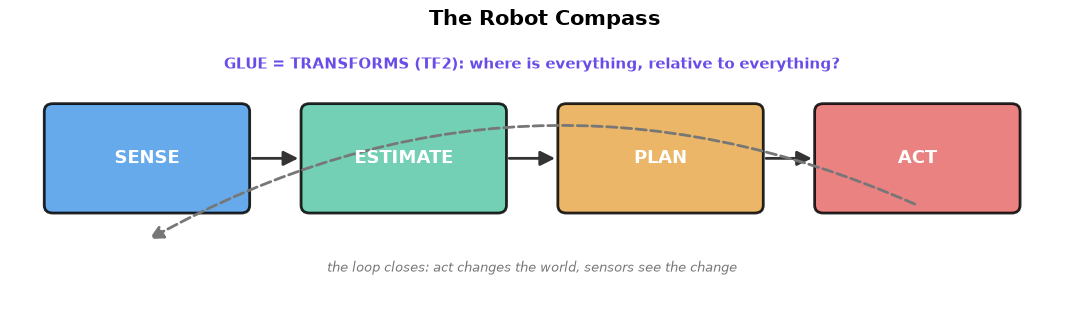

In [2]:
# ▶️ RUN ME — draws your Sense→Estimate→Plan→Act→Glue compass
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

boxes = ["SENSE", "ESTIMATE", "PLAN", "ACT"]
colors = ["#4C9BE8", "#5AC8A8", "#E8A94C", "#E86C6C"]

fig, ax = plt.subplots(figsize=(11, 3.2))
xs = [0, 3, 6, 9]
for x, name, c in zip(xs, boxes, colors):
    ax.add_patch(FancyBboxPatch((x, 1), 2.2, 1.2, boxstyle="round,pad=0.1",
                                linewidth=2, edgecolor="black", facecolor=c, alpha=0.85))
    ax.text(x + 1.1, 1.6, name, ha="center", va="center", fontsize=13, fontweight="bold", color="white")

for x in xs[:-1]:
    ax.add_patch(FancyArrowPatch((x + 2.3, 1.6), (x + 2.9, 1.6),
                 arrowstyle="-|>", mutation_scale=22, linewidth=2, color="#333"))
# feedback loop Act -> Sense
ax.add_patch(FancyArrowPatch((10.1, 1.0), (1.1, 0.55), connectionstyle="arc3,rad=0.25",
             arrowstyle="-|>", mutation_scale=20, linewidth=2, color="#777", linestyle="--"))
ax.text(5.6, 0.15, "the loop closes: act changes the world, sensors see the change",
        ha="center", fontsize=9, color="#777", style="italic")
# glue
ax.text(5.6, 2.75, "GLUE = TRANSFORMS (TF2): where is everything, relative to everything?",
        ha="center", fontsize=11, fontweight="bold", color="#6A4CE8")

ax.set_xlim(-0.5, 12); ax.set_ylim(-0.2, 3.2); ax.axis("off")
ax.set_title("The Robot Compass", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.show()

## 👀 Part 1 — WATCH (~30 min, intuition first)

You're a visual learner, so we always start with the picture before the mechanics.

- **ROS 2 Jazzy Crash Course (2025)** — watch the intro through "what is a node/topic": https://www.youtube.com/watch?v=Se5pvRlTX8s
- **Articulated Robotics** — bookmark this now; it's your home base for the next 3 weeks: https://articulatedrobotics.xyz/

**Watch actively — answer these in your head (or in the journal at the bottom):**
1. Why does ROS split a robot into *many small programs* instead of one big one?
2. What's the difference between a **topic** (publish/subscribe) and a **service** (request/response)? *(We build services on Day 5 — just note the distinction now.)*
3. When would two nodes *not* be able to talk?

## 💡 Part 2 — The ROS 2 graph, intuitively

Forget the jargon for a second. Here's the whole idea:

> **A ROS 2 system is a group chat.**
> - A **node** is a *person* in the chat — one small program with one job (read the LiDAR, drive the wheels, plan a path).
> - A **topic** is a *named group channel* — e.g. `#scan`, `#cmd_vel`, `#odom`.
> - A **message** is a *single text* posted to a channel, with a fixed format (a `std_msgs/String`, a `sensor_msgs/LaserScan`, …).
> - A **publisher** posts to a channel; a **subscriber** reads from it. Nobody needs to know *who* else is in the channel — they just post/read. That anonymity is what makes robots modular: you can swap the "LiDAR person" for a better one and nobody else notices.

Why this matters: your insane software background already knows pub/sub, message buses, microservices. **ROS 2 is a robotics-flavored message bus.** You're not learning a new paradigm — you're learning its dialect and its tooling. That's the whole trick to ROS feeling easy.

The `talker`/`listener` demo you're about to run is literally: one person posting `"Hello World: 1, 2, 3…"` to the `#chatter` channel, and another person reading it out loud.

## 🔧 Part 3a — Sanity-check your environment (terminal)

Open a terminal on your Ubuntu machine. Every new terminal needs ROS 2 "sourced" so it knows the commands exist. Run:

```bash
# Tell this shell where ROS 2 lives (do this in EVERY new terminal…)
source /opt/ros/jazzy/setup.bash

# …or, so you never forget, add it to your shell startup once:
echo "source /opt/ros/jazzy/setup.bash" >> ~/.bashrc
source ~/.bashrc

# Confirm it worked — should print "jazzy":
echo $ROS_DISTRO

# And confirm the CLI is alive:
ros2 --help | head -n 5
```

If `echo $ROS_DISTRO` prints `jazzy`, you're good. If it prints nothing, ROS 2 isn't sourced — re-run the `source` line. *(This "did you source it?" is the #1 ROS gotcha for your entire first week. When something says "command not found" or a node can't be found, suspect sourcing first.)*

## 🛠️ Part 3b — BUILD: make two programs talk

You'll need **three terminals** (all sourced — see above). Tip: `Ctrl+Shift+T` opens a new tab.

**Terminal 1 — the talker (publisher):**
```bash
ros2 run demo_nodes_cpp talker
# → prints:  [INFO] Publishing: 'Hello World: 1'  ... 2 ... 3 ...
```

**Terminal 2 — the listener (subscriber):**
```bash
ros2 run demo_nodes_py listener
# → prints:  [INFO] I heard: 'Hello World: 1'  ... 2 ... 3 ...
```

🎉 Two independent programs — one written in C++, one in Python — are now talking, and neither knows the other exists. They only share the channel name `/chatter`. **That decoupling is the soul of ROS.**

Leave both running and open **Terminal 3** to *inspect the live system* like a roboticist:
```bash
ros2 node list           # who is in the system?      → /talker  /listener
ros2 topic list          # what channels exist?        → /chatter  /parameter_events  /rosout
ros2 topic info /chatter # who's on this channel?      → 1 publisher, 1 subscriber
ros2 topic echo /chatter # eavesdrop on the messages   → prints each "Hello World" as it flies by
ros2 topic hz /chatter   # how fast are messages sent? → ~1 Hz
ros2 interface show std_msgs/msg/String   # what's IN a message? → "string data"
```

These five commands (`node list`, `topic list/info/echo/hz`, `interface show`) are your **debugging stethoscope**. You will use them every single day for 45 days. Get them into muscle memory now.

### See the graph with your own eyes 👁️

With talker + listener still running, in a fourth terminal:
```bash
rqt_graph
```
A window opens showing **`/talker` → `/chatter` → `/listener`** as a literal diagram. This is the "group chat" made visible.

**✅ Checkpoint — before moving on, you should be able to answer:**
- Which node is the publisher? Which is the subscriber?
- What is the *message type* on `/chatter`? *(hint: `ros2 topic info /chatter --verbose`)*
- If you `Ctrl+C` the talker, what does `ros2 topic hz /chatter` do? *(try it — this is how you'll diagnose "why is my robot frozen?" later)*

When done exploring, `Ctrl+C` in the talker and listener terminals to stop them.

## ✍️ Part 4 — BUILD: write your *own* publisher node

Watching a demo is one thing; writing a node is where it becomes yours. We'll make a package and a node that publishes a greeting.

### 4.1 — Create a workspace + package (terminal)
```bash
# A ROS 2 workspace is just a folder with a src/ inside.
mkdir -p ~/robotics_ws/src
cd ~/robotics_ws/src

# Scaffold a Python package that depends on rclpy (ROS client lib) and std_msgs (message types):
ros2 pkg create --build-type ament_python my_first_pkg --dependencies rclpy std_msgs
```
This makes `~/robotics_ws/src/my_first_pkg/` with a `package.xml`, `setup.py`, and an inner `my_first_pkg/` folder where node code lives.

### 4.2 — Generate the node file (run the ▶️ cell below)
The next cell **writes the node to disk in this notebook's folder** so you have it as a clean reference. After running it, copy the file into your package (command shown under the cell).

In [1]:
# ▶️ RUN ME — writes your first ROS 2 node to 'my_first_node.py' next to this notebook.
node_code = '''#!/usr/bin/env python3
# My first ROS 2 node: publishes a greeting to /greetings once per second.
import rclpy                       # the ROS 2 Python client library
from rclpy.node import Node        # base class for every node
from std_msgs.msg import String    # the message type we will publish


class GreetingPublisher(Node):
    def __init__(self):
        super().__init__("greeting_publisher")          # <- the node name in the graph
        # create a publisher: (message type, topic name, queue size)
        self.pub = self.create_publisher(String, "greetings", 10)
        # call self.tick() every 1.0 seconds
        self.timer = self.create_timer(1.0, self.tick)
        self.count = 0
        self.get_logger().info("greeting_publisher is up. Posting to /greetings ...")

    def tick(self):
        msg = String()
        msg.data = f"Hello from Filippo's first node! #{self.count}"
        self.pub.publish(msg)                           # post to the channel
        self.get_logger().info(f"Published: {msg.data}")
        self.count += 1


def main(args=None):
    rclpy.init(args=args)          # start up ROS 2
    node = GreetingPublisher()
    try:
        rclpy.spin(node)           # keep the node alive, firing the timer
    except KeyboardInterrupt:
        pass
    finally:
        node.destroy_node()
        rclpy.shutdown()


if __name__ == "__main__":
    main()
'''
with open("my_first_node.py", "w") as f:
    f.write(node_code)
print("Wrote my_first_node.py  (", len(node_code), "bytes )")
print("Read it below, then copy it into your package with the command in the next cell.")

Wrote my_first_node.py  ( 1400 bytes )
Read it below, then copy it into your package with the command in the next cell.


**Read the node you just generated.** Notice the anatomy every ROS 2 node shares: `__init__` sets up publishers/subscribers/timers → a callback (`tick`) does the work → `main` calls `rclpy.init`, `spin`, `shutdown`. Ninety percent of nodes you ever write follow this skeleton.

### 4.3 — Install the node into your package (terminal)
```bash
# Copy the generated file into your package's code folder:
cp ~/path/to/this/notebook/my_first_node.py ~/robotics_ws/src/my_first_pkg/my_first_pkg/greeting_publisher.py
```
*(Replace `~/path/to/this/notebook/` with wherever you saved this notebook. If you ran the cell above from this notebook's folder, the file is right there.)*

### 4.4 — Register an entry point so `ros2 run` can find it
Open `~/robotics_ws/src/my_first_pkg/setup.py` and find the `entry_points` block. Make it look like this:
```python
    entry_points={
        'console_scripts': [
            'greeting = my_first_pkg.greeting_publisher:main',
        ],
    },
```
This says: the command `greeting` runs the `main()` function in `greeting_publisher.py`.

### 4.5 — Build and run (terminal)
```bash
cd ~/robotics_ws
colcon build --packages-select my_first_pkg   # compile/install the package
source install/setup.bash                     # <- source YOUR workspace (on top of /opt/ros)
ros2 run my_first_pkg greeting                # 🚀 run your node!
```
You should see your greeting printed once a second. **In another terminal, prove it's really on the graph:**
```bash
ros2 topic echo /greetings
```
Your own messages, flying across the bus. That's your first node. 🎉

> 🐛 **If it doesn't work**, walk the checklist (this IS the skill): (1) did you `source install/setup.bash` in *this* terminal? (2) did `colcon build` succeed with no red errors? (3) does `setup.py` have the exact entry-point line? (4) `ros2 pkg executables my_first_pkg` — does `greeting` show up? Log whatever bit you here in the journal.

## 🏋️ Part 5 — STRETCH (deliberate practice, ~15 min)

Do this **without copying** — struggling here is the point.

**Challenge:** modify your node so that instead of a counter, it publishes the **current time** every second (e.g. `"The time is 14:32:07"`).

Hints, not answers: you'll need Python's `datetime`, and you'll edit only the `tick()` method. Rebuild (`colcon build`), re-source, re-run, and confirm with `ros2 topic echo /greetings`.

**Bonus (if that was easy):** make the publish rate a **parameter** so you can change it at launch without editing code. *(You don't know parameters yet — that's Day 5. Try to find it in the docs anyway; learning to read docs is a robotics superpower. If you get it, you're ahead.)*

## 📓 Part 6 — LOG (5 min, non-negotiable)

This is what turns 45 scattered days into a portfolio and a memory. Mirror Alex Xu's model exactly.

### Start your public repo (terminal, one time)
```bash
cd ~/robotics_ws            # or a dedicated ~/robotics-from-scratch folder
git init
# create a README that will grow into your "series"
printf "# Robotics From Scratch\n\nMy 45-day ground-up robotics journey (sim-only, ROS 2).\n\n## Log\n- **Day 1:** The robotics stack + first ROS 2 graph + first publisher node.\n" > README.md
# create your debug journal
printf "# Debug Journal\n\n## Day 1\n- What broke:\n- Why:\n- How I fixed it:\n" > journal.md
git add -A && git commit -m "Day 1: first ROS 2 graph and publisher node"
```
Then create an empty repo on GitHub and push (`git remote add origin ... && git push -u origin main`).

### Fill in three lines (run the ▶️ cell, or just write them in journal.md)

In [ ]:
# ▶️ RUN ME (optional) — append today's reflection to a local journal.md next to this notebook.
what_broke  = "…"   # e.g. "ros2 run couldn't find my node"
why         = "…"   # e.g. "forgot to source install/setup.bash after colcon build"
how_i_fixed = "…"   # e.g. "sourced it; also added to .bashrc"

entry = f'''## Day 1
- What broke: {what_broke}
- Why: {why}
- How I fixed it: {how_i_fixed}
- Wins: ran talker/listener, inspected the graph, wrote greeting_publisher, published /greetings.
'''
with open("journal.md", "a") as f:
    f.write(entry)
print("Appended to journal.md:\n"); print(entry)

## 🧑‍🏫 Bonus — teach it back (your unfair advantage)

You're President of Yale Undergraduate Robotics. The fastest way to *cement* today is to prepare to explain it. In one or two sentences, how would you explain "what is a ROS node/topic" to a brand-new club member who's never touched robotics? Write it in your README. Over 45 days these become a real onboarding track for the club — and teaching is the single best retention tool there is.

### ANS:

A node is a program that performs a specific action/computation. It is modular.

BTW:
Topics, services, and actions are all communication methods between nodes.

**A publisher and subscriber are roles used by topics only.**

## ✅ Recap & tomorrow

**Today you:** installed the Sense→Estimate→Plan→Act→Glue compass · learned ROS 2 as a "robotics message bus" · ran and *inspected* a live system with your debugging stethoscope · wrote, built, and ran your **own** publisher node · started your repo + journal.

**You can now genuinely say:** *"I understand how a ROS 2 system is wired, and I've written a node."* That's more than most people who call themselves ROS users.

**Day 2 — Linear algebra you can *see*.** We shift to the math backbone (rotations & transforms), 3Blue1Brown-style: pure visual intuition first, then a NumPy notebook where you rotate and plot frames. It's the language of *where things are* — the "Glue" box — and it unlocks everything mechanical that follows.

> 🔒 **Before you close:** are talker/listener stopped (`Ctrl+C`)? Is your work committed? Is `source /opt/ros/jazzy/setup.bash` in your `~/.bashrc`? Good. See you on Day 2. 🤖